In [1]:
%cd /Data/gfi/users/rogui7909/code/predict_rain_norway

/felles_gfi/felles_gfi_users/rogui7909/code/predict_rain_norway


In [2]:
print('Running imports...')
import os
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"

import wandb
import numpy as np
import torch # long
import xarray as xr

from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits
from models.model import CNN_Model, CNN_Model_ChannelAttention, CNN_Model_SpatialAttention
import pandas as pd
from torch import nn
from lightning.pytorch import loggers, seed_everything
from models.lightning import LitCNN_regression, AttributableTrainer
# from models.losses import get_loss
import matplotlib
from models.data import get_input_data_from_wandb_logger,get_input_data_from_wandb_logger_three_types
# from models.model import get_model
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
plt.style.use('robin')
# matplotlib.use('tkagg')
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)
import seaborn as sns 
import argparse
from tqdm.notebook import tqdm
import cartopy.crs as ccrs

Running imports...


Seed set to 42


In [3]:
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_backtoclassif", 
                                    save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                    dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

wandb_logger.experiment # Initialize wandb

train_loader, val_loader, test_loader, ds_test = get_input_data_from_wandb_logger_three_types(wandb_logger)#, lon_lim=(-128, 53))

callbacks=[EarlyStopping(monitor="val/loss", mode="min")]
trainer = AttributableTrainer(limit_train_batches=100, 
                                max_epochs=wandb_logger.experiment.config['num_epochs'], 
                                logger=wandb_logger, 
                                log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                                callbacks=callbacks, deterministic=True,
                                accelerator="gpu", devices=1,)

wandb_logger.experiment.config['num_classes'] = wandb_logger.experiment.config['num_timesteps_predicted']*3
wandb_logger.experiment.config['num_channels'] = len(wandb_logger.experiment.config['input_variables'])

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Data ready:
    Image size: 4096 (128x32)
    Input data: u850, v850
    4 Predicted timesteps for future rainfall
    90th percentile predicted


In [4]:

class CNN_Model_(nn.Module):
    def __init__(self, 
                 input_channels, 
                 image_size, 
                 num_timesteps,
                 number_conv_layers=3,
                 size_conv_kernel=3,
                 out_channels_conv1=12, 
                 out_channel_factor_increase_per_layer = 2,
                 ):
        super(CNN_Model_, self).__init__()
        
        # CNN layers to extract spatial features
        # self.sigmoid = sigmoid
        # self.softmax = softmax
        self.num_timesteps = num_timesteps
        self.classes_per_timestep = 3
        self.num_classes = self.num_timesteps*(self.classes_per_timestep-1)
        self.conv_layer1 = nn.Sequential(
                                nn.Conv2d(input_channels, 
                                          out_channels_conv1, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.ReLU(),
                                nn.MaxPool2d(kernel_size=2, stride=2))
        self.conv_layer2 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          kernel_size=size_conv_kernel, 
                                          stride=2, padding=(size_conv_kernel-1)//2),
                                # nn.ReLU(),
                                nn.MaxPool2d(kernel_size=2, stride=2))
        self.conv_layer3 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          kernel_size=size_conv_kernel, stride=1, padding=(size_conv_kernel-1)//2),
                                nn.ReLU(),
                                nn.MaxPool2d(kernel_size=2, stride=2))
        self.conv_layer4 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**3, 
                                          kernel_size=size_conv_kernel, stride=1, padding=(size_conv_kernel-1)//2),
                                nn.ReLU(),
                                nn.MaxPool2d(kernel_size=2, stride=2))
        
        if number_conv_layers == 1:
            self.cnn = nn.Sequential(self.conv_layer1)
        elif number_conv_layers == 2:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2)
        elif number_conv_layers == 3:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3)
        elif number_conv_layers == 4:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4)
        
        max_pools = 4**(number_conv_layers)
        self.output_cnn_channels  = out_channels_conv1*out_channel_factor_increase_per_layer**(number_conv_layers-1)
        self.linear_size = image_size * self.output_cnn_channels // max_pools 
        self.fc = nn.Linear(self.linear_size, self.num_classes)
    
    def forward(self, x):
        # x shape: (batch_size, seq_length, channels, height, width)
        # Apply CNN to extract spatial features
        batch_size,  channels, height, width = x.size()
        cnn_out = self.cnn(x)
        cnn_out = cnn_out.view(batch_size, -1)  # Shape: (batch_size, seq_length, features)
        output = self.fc(cnn_out)  # Shape: (batch_size, output_size)
        output = output.view(-1, self.num_timesteps, self.classes_per_timestep-1)
        output = torch.sigmoid(output) 
        X1 = output[:,:,0]
        X2 = output[:,:,1]
        P_norain = X1 
        P_rain = (1-X1)*(1-X2)
        P_extreme = (1-X1)*X2
        output = torch.stack([P_norain, P_rain, P_extreme], dim=2)
        return output.view(-1, self.num_timesteps*self.classes_per_timestep)
        # print(output.shape)
    

class CNN_Model_2(nn.Module):
    def __init__(self, 
                 input_channels, 
                 image_size, 
                 num_timesteps,
                 number_conv_layers=3,
                 size_conv_kernel=3,
                 out_channels_conv1=12, 
                 out_channel_factor_increase_per_layer = 2,
                 ):
        super(CNN_Model_2, self).__init__()
        
        # CNN layers to extract spatial features
        # self.sigmoid = sigmoid
        # self.softmax = softmax
        self.num_timesteps = num_timesteps
        self.classes_per_timestep = 3
        self.num_classes = self.num_timesteps*(self.classes_per_timestep-1)
        self.conv_layer1 = nn.Sequential(
                                     nn.Conv2d(input_channels, 
                                     out_channels_conv1, 
                                     kernel_size=size_conv_kernel, 
                                     stride=1, padding=(size_conv_kernel-1)//2),
                            nn.MaxPool2d(kernel_size=2, stride=2),
                            nn.ReLU())
        self.conv_layer2 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer3 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          kernel_size=size_conv_kernel, stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer4 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**3, 
                                          kernel_size=size_conv_kernel, stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        
        if number_conv_layers == 1:
            self.cnn = nn.Sequential(self.conv_layer1)
        elif number_conv_layers == 2:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2)
        elif number_conv_layers == 3:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3)
        elif number_conv_layers == 4:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4)
        
        max_pools = 4**(number_conv_layers)
        self.output_cnn_channels  = out_channels_conv1*out_channel_factor_increase_per_layer**(number_conv_layers-1)
        self.linear_size = image_size * self.output_cnn_channels // max_pools 
        self.fc = nn.Linear(self.linear_size, self.num_classes)
    
    def forward(self, x):
        # x shape: (batch_size, seq_length, channels, height, width)
        # Apply CNN to extract spatial features
        batch_size,  channels, height, width = x.size()
        cnn_out = self.cnn(x)
        cnn_out = cnn_out.view(batch_size, -1)  # Shape: (batch_size, seq_length, features)
        output = self.fc(cnn_out)  # Shape: (batch_size, output_size)
        output = output.view(-1, self.num_timesteps, self.classes_per_timestep-1)
        output = torch.sigmoid(output) 
        X1 = output[:,:,0]
        X2 = output[:,:,1]
        P_norain = X1 
        P_rain = (1-X1)*(1-X2)
        P_extreme = (1-X1)*X2
        output = torch.stack([P_norain, P_rain, P_extreme], dim=2)
        return output.view(-1, self.num_timesteps*self.classes_per_timestep)
        # print(output.shape)
        



In [5]:
NN = CNN_Model_2(input_channels = wandb_logger.experiment.config['num_channels'], 
               image_size=wandb_logger.experiment.config['image_size'], 
               num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
               number_conv_layers=wandb_logger.experiment.config['num_conv_layer'],
               size_conv_kernel=wandb_logger.experiment.config['size_conv_kernel'],
               out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'], 
               out_channel_factor_increase_per_layer = wandb_logger.experiment.config['factor_increase_kernels_per_conv_layer'],)
 

class MultiCrossEntropyLoss(nn.Module):
    def __init__(self, timesteps):
        super(MultiCrossEntropyLoss, self).__init__()
        self.nll = torch.nn.NLLLoss(weight = torch.Tensor([1,1,8]))
        self.timesteps = timesteps
        
    def forward(self, pred, target):
        """
        Computes the loss for the given prediction.
        """
        loss = []
        pred = pred.view(-1, self.timesteps, 3)
        proba = torch.softmax(pred, dim=2)
        for k,timestep in enumerate(range(self.timesteps)):
            res = self.nll(torch.log(proba[:,timestep]), target[:,timestep])
            loss.append(res)#*(k+1)/10)
        loss = torch.mean(torch.stack(loss))
        return loss
    

loss = MultiCrossEntropyLoss(timesteps = wandb_logger.experiment.config['num_timesteps_predicted'])


model = LitCNN_regression(NN, 
                          learning_rate=wandb_logger.experiment.config['learning_rate'], 
                          lr_scheduler =wandb_logger.experiment.config['lr_scheduler'],
                          loss_fn = loss)


In [ ]:
trainer.fit(model, train_loader, val_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type                  | Params | Mode 
----------------------------------------------------------
0 | model   | CNN_Model_2           | 316 K  | train
1 | loss_fn | MultiCrossEntropyLoss | 0      | train
----------------------------------------------------------
316 K     Trainable params
0         Non-trainable params
316 K     Total params
1.267     Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


In [ ]:
model.eval()
with torch.no_grad():
    trainer.test(model, dataloaders=val_loader)
wandb.finish()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.9214075803756714     │
└───────────────────────────┴───────────────────────────┘

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇████
test/loss,▁
train/loss,▇▇▇█▇▆▆▅▄▄▄▄▄▃▄▃▃▃▃▃▃▃▂▂▂▃▂▂▃▂▂▃▂▃▂▂▁▂▁▂
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇█████
val/loss,█▆▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,24
test/loss,0.92141
train/loss,0.85585
trainer/global_step,624
val/loss,0.92141


In [ ]:
y_test = torch.stack(model.test_true_values)#.cpu().numpy()
y_scores = torch.stack(model.test_pred).view(-1, wandb_logger.experiment.config['num_timesteps_predicted'], 3)#.cpu().numpy()
preds = torch.argmax(y_scores, dim=2)
targets=xr.DataArray(y_test.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time, timestep=np.arange(y_scores.shape[1])))
preds=xr.DataArray(preds.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time, timestep=np.arange(y_scores.shape[1])))
proba=xr.DataArray(y_scores.cpu().numpy(), dims=['time','timestep','type_rain'], 
                   coords=dict(time=ds_test.time, timestep=np.arange(y_scores.shape[1]), type_rain=['no_rain','moderate_rain','extreme_rain']))
df_=pd.DataFrame(dict(pred=preds.to_series(), targets=targets.to_series()))
df_['pred_time'] = (df_.index.get_level_values(0)+pd.Timedelta(1,'D')*df_.index.get_level_values(1)).values
# model.test_true_values

# pred = torch.stack([corn_label_from_logits(y_scores[:,k]) for k in range(y_scores.shape[1])])

[Text(0, 0, 'D0'), Text(1, 0, 'D+1'), Text(2, 0, 'D+2'), Text(3, 0, 'D+3')]

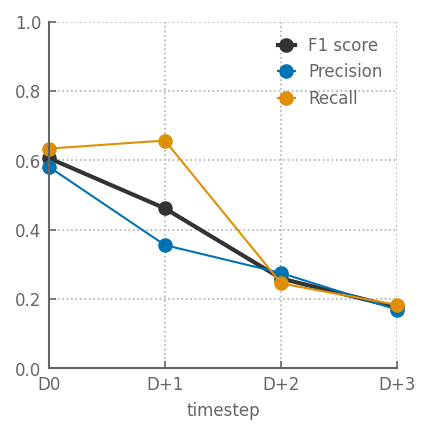

In [ ]:
TP = ((preds == targets)&(targets==2)).sum('time')
recall = TP / (targets==2).sum('time')
precision = TP / (preds==2).sum('time')
f1 = 2*(precision*recall)/(precision+recall)



# recall_season.plot(hue='season')
fig, ax = plt.subplots(figsize=(3,3,))
f1.plot(color='.2', lw=2, label='F1 score', marker='o', clip_on=False)
precision.plot(label='Precision', marker='o', clip_on=False)
recall.plot(label='Recall', marker='o', clip_on=False)
plt.legend()
ax.set_ylim(0,1)
ax.grid()
ax.set_xlim(0,3)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['D0','D+1','D+2','D+3'])

In [ ]:
df_=pd.DataFrame(dict(pred=preds.to_series(), targets=targets.to_series()))
df_['pred_time'] = (df_.index.get_level_values(0)+pd.Timedelta(1,'D')*df_.index.get_level_values(1)).values

times = df_.query("targets==2 & pred==2").groupby('pred_time').count().pred.sort_values()
events_predicted = times.loc[times>3].index
steps = 4
start_times = events_predicted -  pd.Timedelta(steps-1,'D')
print("Number of 4x events:",len(start_times))
num_extremes = df_.targets.loc[df_.targets==2].unstack().count(axis=1)
num_extremes_pred = df_.targets.where((df_.targets==2)&(df_.pred==2)).fillna(0).unstack().sum(axis=1)//2
pred_failed = df_.query("targets==2 & pred<2").groupby('pred_time').count().query("pred==4").index

start_times_failed = pred_failed - pd.Timedelta(steps-1,'D')
# events

DatetimeIndex(['2000-01-05', '2001-10-26', '2005-11-09', '2001-10-09',
               '2000-02-24', '1997-02-27', '1998-12-22', '2001-11-18',
               '2005-01-09', '2005-01-05', '2005-01-04', '2003-01-14',
               '2005-01-01', '2004-12-30', '2004-12-27', '1998-12-14',
               '2003-09-19', '1998-02-24', '1997-09-05', '2001-10-31',
               '2000-02-03'],
              dtype='datetime64[ns]', name='pred_time', freq=None)